[![Roboflow Notebooks](https://ik.imagekit.io/roboflow/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLOv8 Instance Segmentation on a Custom Dataset

---

[![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/how-to-train-yolov8-on-a-custom-dataset)
[![YouTube](https://badges.aleen42.com/src/youtube.svg)](https://youtu.be/wuZtUMEiKWY)
[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

Ultralytics YOLOv8 is a popular version of the YOLO (You Only Look Once) object detection and image segmentation model developed by Ultralytics. The YOLOv8 model is designed to be fast, accurate, and easy to use, making it an excellent choice for a wide range of object detection and image segmentation tasks. It can be trained on large datasets and is capable of running on a variety of hardware platforms, from CPUs to GPUs.

## Accompanying Blog Post

We recommend that you follow along in this notebook while reading the accompanying [blog post](https://blog.roboflow.com/how-to-train-yolov8-instance-segmentation/).

## Pro Tip: Use GPU Acceleration

If you are running this notebook in Google Colab, navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`. This will ensure your notebook uses a GPU, which will significantly speed up model training times.

## Steps in this Tutorial

In this tutorial, we are going to cover:

- Before you start
- Install YOLOv8
- CLI Basics
- Inference with Pre-trained COCO Model
- Roboflow Universe
- Preparing a custom dataset
- Custom Training
- Validate Custom Model
- Inference with Custom Model
- Deploy the Trained Model to Roboflow

**Let's begin!**

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Tue Apr  1 12:11:14 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
import os
HOME = os.getcwd()
print(HOME)

/content/{HOME}


## Install YOLOv8

YOLOv8 can be installed in two ways - from the source and via pip. This is because it is the first iteration of YOLO to have an official package.

In [3]:
# Pip install method (recommended)

!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.3/112.6 GB disk)


In [4]:
from ultralytics import YOLO

from IPython.display import display, Image

## CLI Basics

If you want to train, validate or run inference on models and don't need to make any modifications to the code, using YOLO command line interface is the easiest way to get started. Read more about CLI in [Ultralytics YOLO Docs](https://docs.ultralytics.com/usage/cli/).

```
yolo task=detect    mode=train    model=yolov8n.yaml      args...
          classify       predict        yolov8n-cls.yaml  args...
          segment        val            yolov8n-seg.yaml  args...
                         export         yolov8n.pt        format=onnx  args...
```

## Inference with Pre-trained COCO Model

### 💻 CLI

`yolo mode=predict` runs YOLOv8 inference on a variety of sources, downloading models automatically from the latest YOLOv8 release, and saving results to `runs/predict`.

In [ ]:
%cd {HOME}
!yolo task=segment mode=predict model=yolov8s-seg.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=true

/content
100% 22.8M/22.8M [00:00<00:00, 97.3MB/s]
Ultralytics YOLOv8.2.103 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8s-seg summary (fused): 195 layers, 11,810,560 parameters, 0 gradients, 42.6 GFLOPs

100% 104k/104k [00:00<00:00, 64.1MB/s]
image 1/1 /content/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 1 backpack, 1 handbag, 83.6ms
Speed: 12.7ms preprocess, 83.6ms inference, 1527.9ms postprocess per image at shape (1, 3, 640, 384)
Results saved to runs/segment/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


/content


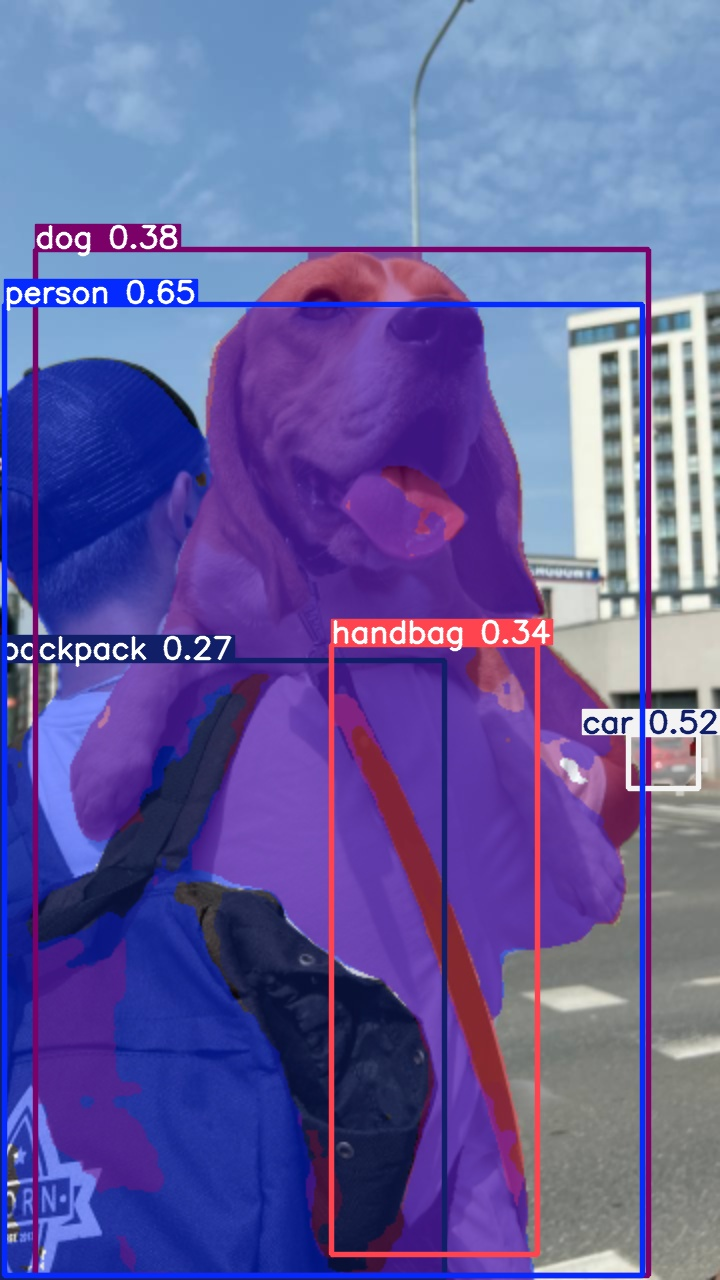

In [ ]:
%cd {HOME}
Image(filename='runs/segment/predict/dog.jpeg', height=600)

### 🐍 Python SDK

The simplest way of simply using YOLOv8 directly in a Python environment.

In [ ]:
model = YOLO(f'{HOME}/yolov8s-seg.pt')
results = model.predict(source='https://media.roboflow.com/notebooks/examples/dog.jpeg', conf=0.25)


Found https://media.roboflow.com/notebooks/examples/dog.jpeg locally at dog.jpeg
WARNING ⚠️ NMS time limit 2.050s exceeded
image 1/1 /content/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 1 backpack, 1 handbag, 116.7ms
Speed: 2.3ms preprocess, 116.7ms inference, 2392.8ms postprocess per image at shape (1, 3, 640, 384)


In [ ]:
results[0].boxes.xyxy

tensor([[4.4446e+00, 3.0434e+02, 6.4261e+02, 1.2755e+03],
        [6.2834e+02, 7.3451e+02, 6.9819e+02, 7.8832e+02],
        [3.5369e+01, 2.4992e+02, 6.4884e+02, 1.2759e+03],
        [3.3150e+02, 6.4431e+02, 5.3794e+02, 1.2545e+03],
        [8.8925e-01, 6.6045e+02, 4.4417e+02, 1.2785e+03]], device='cuda:0')

In [ ]:
results[0].boxes.conf

tensor([0.6489, 0.5239, 0.3784, 0.3442, 0.2668], device='cuda:0')

In [ ]:
results[0].boxes.cls

tensor([ 0.,  2., 16., 26., 24.], device='cuda:0')

In [ ]:
results[0].masks.data

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 

## Roboflow Universe

Need data for your project? Before spending time on annotating, check out Roboflow Universe, a repository of more than 110,000 open-source datasets that you can use in your projects. You'll find datasets containing everything from annotated cracks in concrete to plant images with disease annotations.


[![Roboflow Universe](https://ik.imagekit.io/roboflow/notebooks/template/uni-banner-frame.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672878480290)](https://universe.roboflow.com/)



## Preparing a custom dataset

Building a custom dataset can be a painful process. It might take dozens or even hundreds of hours to collect images, label them, and export them in the proper format. Fortunately, Roboflow makes this process as straightforward and fast as possible. Let me show you how!

### Step 1: Creating project

Before you start, you need to create a Roboflow [account](https://app.roboflow.com/login). Once you do that, you can create a new project in the Roboflow [dashboard](https://app.roboflow.com/). Keep in mind to choose the right project type. In our case, Object Detection.

<div align="center">
  <img
    width="640"
    src=""
  >
</div>

### Step 2: Uploading images

Next, add the data to your newly created project. You can do it via API or through our [web interface](https://docs.roboflow.com/adding-data/object-detection).

If you drag and drop a directory with a dataset in a [supported format](https://roboflow.com/formats), the Roboflow dashboard will automatically read the images and annotations together.

<div align="center">
  <img
    width="640"
    src="https://ik.imagekit.io/roboflow/preparing-custom-dataset-example/uploading-images.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672929808290"
  >
</div>

### Step 3: Generate new dataset version

Now that we have our images and annotations added, we can Generate a Dataset Version. When Generating a Version, you may elect to add preprocessing and augmentations. This step is completely optional, however, it can allow you to significantly improve the robustness of your model.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/generate-new-version.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1673003597834"
  >
</div>

### Step 4: Exporting dataset

Once the dataset version is generated, we have a hosted dataset we can load directly into our notebook for easy training. Click `Export` and select the `YOLOv8` dataset format.

<div align="center">
  <img
    width="640"
    src="https://ik.imagekit.io/roboflow/preparing-custom-dataset-example/export.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672943313709"
  >
</div>




🟢 Tip: The examples below work even if you use our non-custom model. However, you won't be able to deploy it to Roboflow. To do that, create a custom dataset as described below or fork (copy) one into your workspace from Universe.

In [1]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="7RIsDIQB7f0cmuKkOFXY")
project = rf.workspace("dataset-dngc8").project("dust-detection-pohv8")
version = project.version(6)
dataset = version.download("yolov8")


/content/{HOME}/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dust-detection-6 in yolov8:: 100%|██████████| 2396/2396 [00:00<00:00, 3637.22it/s]


## Custom Training

In [2]:
%cd {HOME}

!yolo task=segment mode=train model=yolov8l-seg.pt data={dataset.location}/data.yaml epochs=175 imgsz=640 optimizer='SGD'

[Errno 2] No such file or directory: '{HOME}'
/content/{HOME}/datasets
100% 88.1M/88.1M [00:02<00:00, 34.7MB/s]
New https://pypi.org/project/ultralytics/8.3.99 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=segment, mode=train, model=yolov8l-seg.pt, data=/content/{HOME}/datasets/dust-detection-6/data.yaml, epochs=175, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_strid

/content/{HOME}/datasets


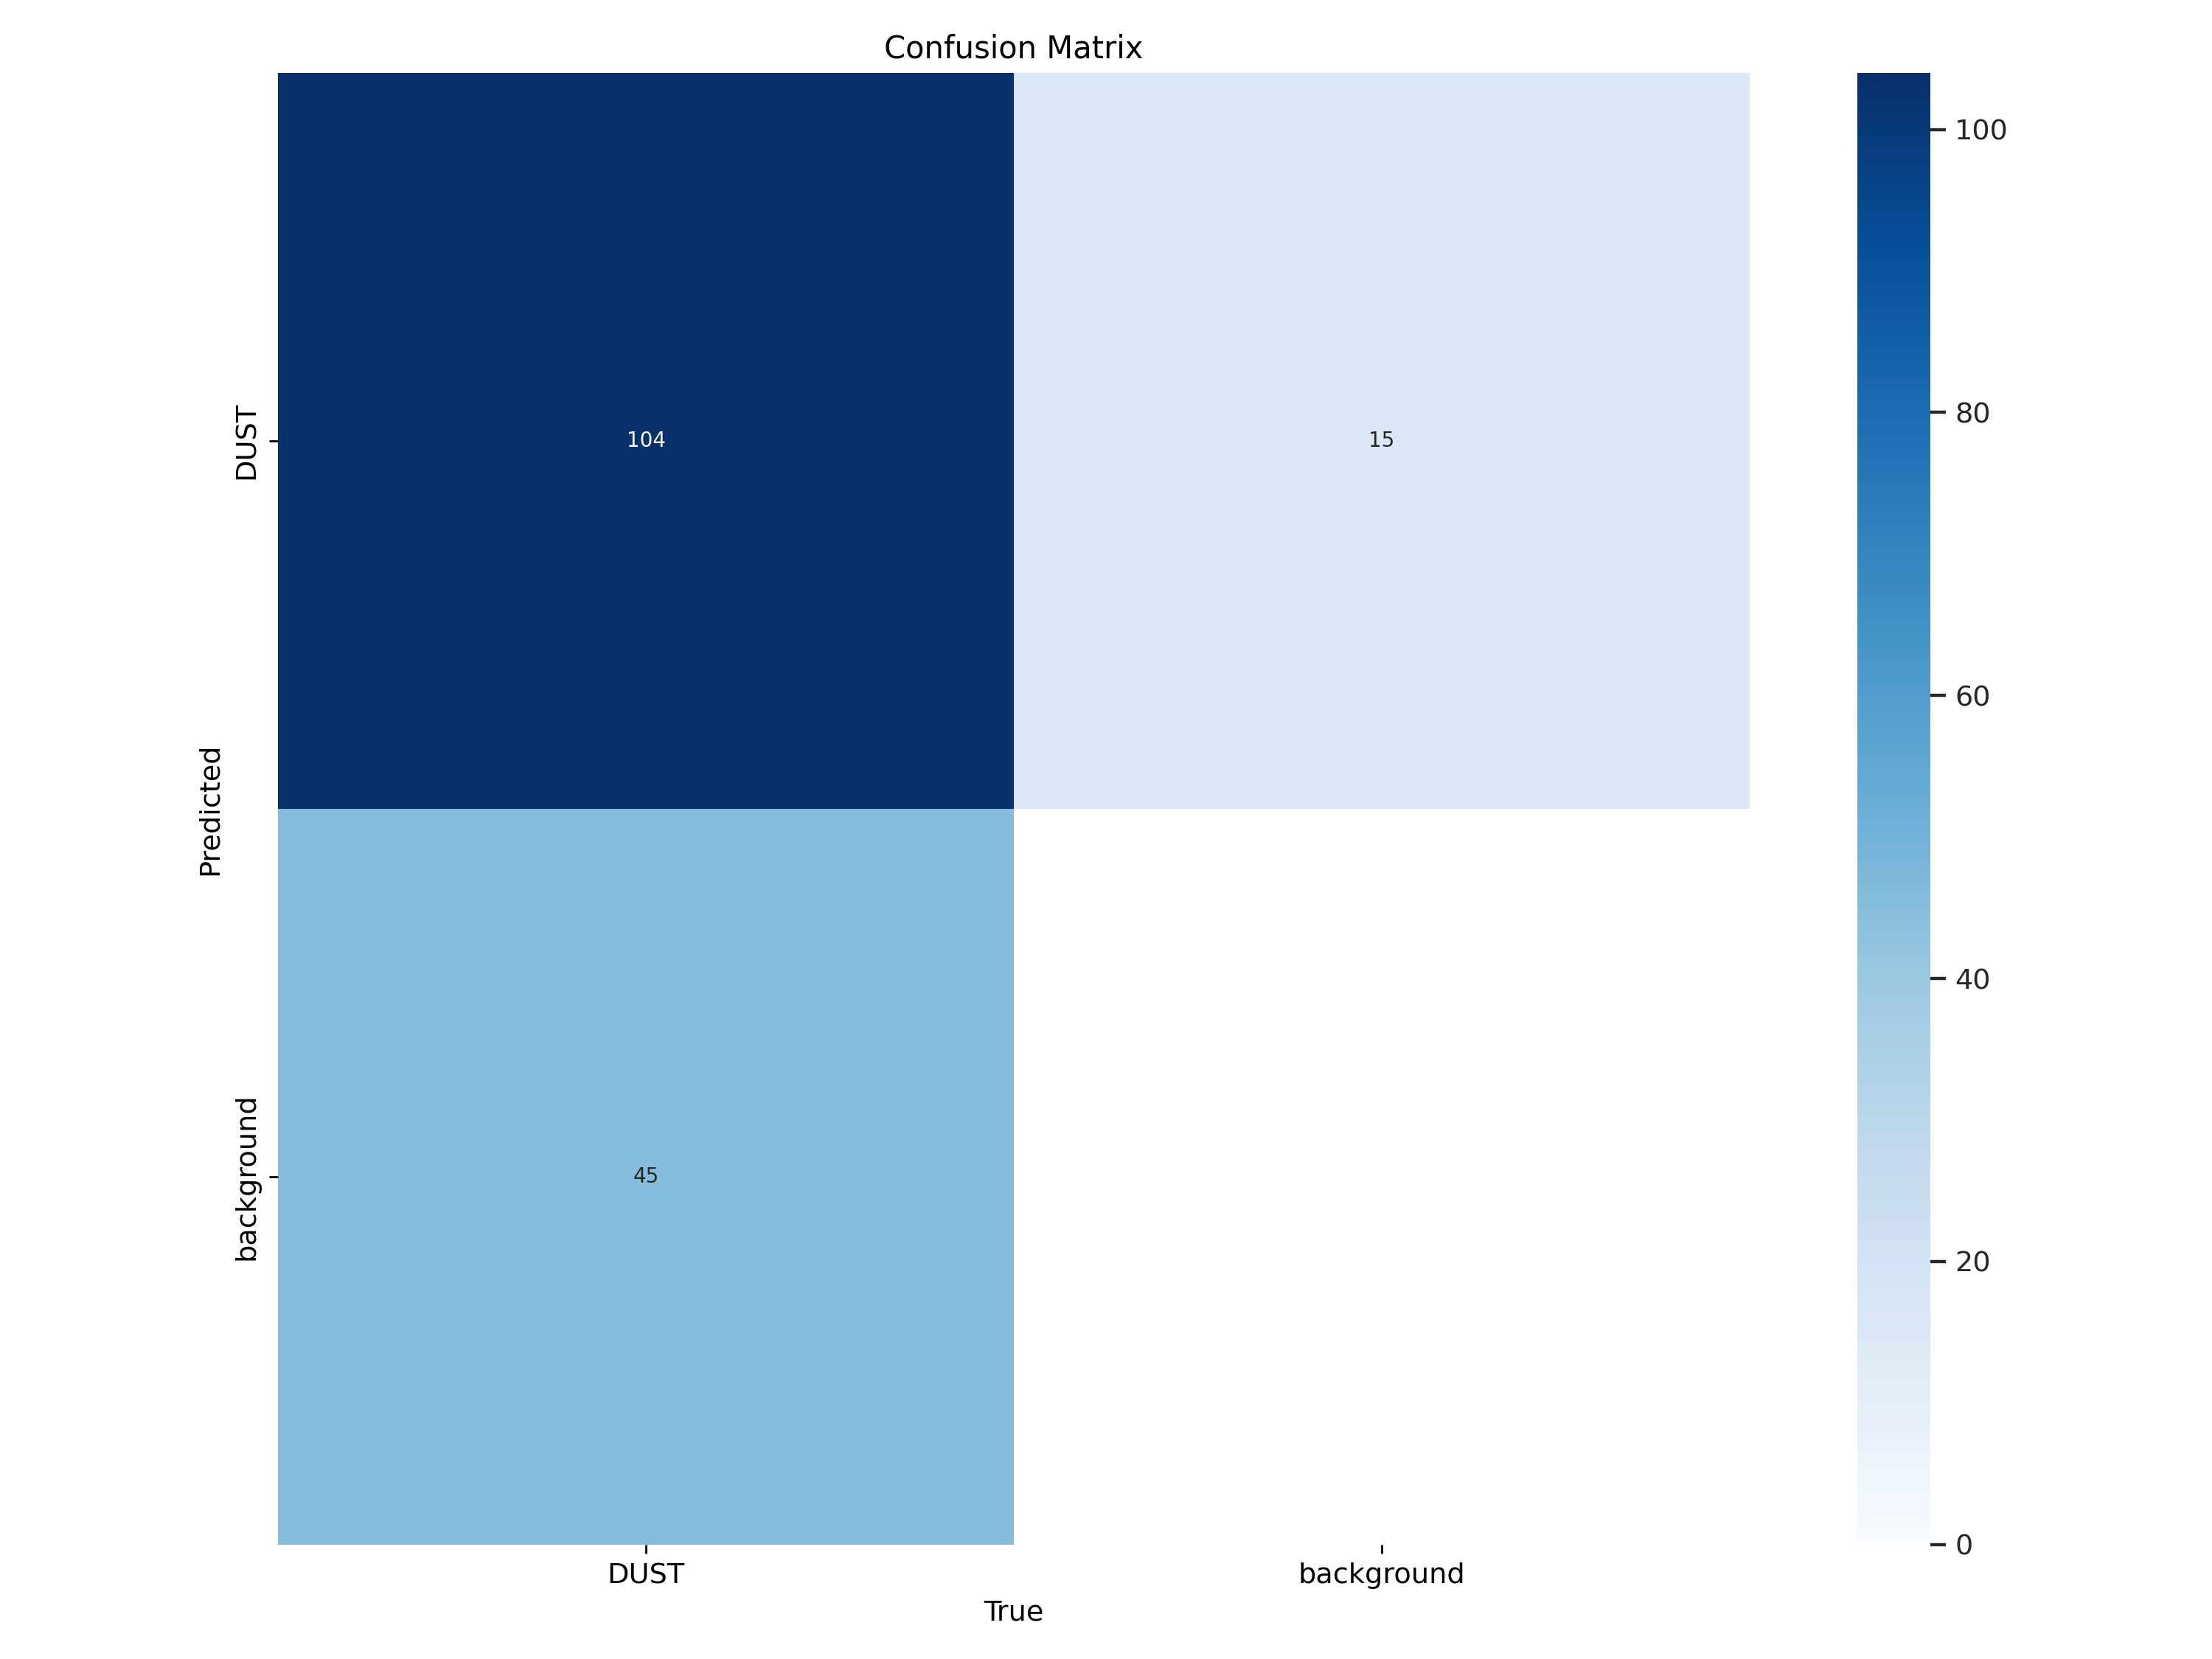

In [6]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/confusion_matrix.png', width=600)

In [6]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/results.png', width=1280)

/content/{HOME}


FileNotFoundError: [Errno 2] No such file or directory: '/content/{HOME}/runs/segment/train/results.png'

/content/{HOME}/datasets


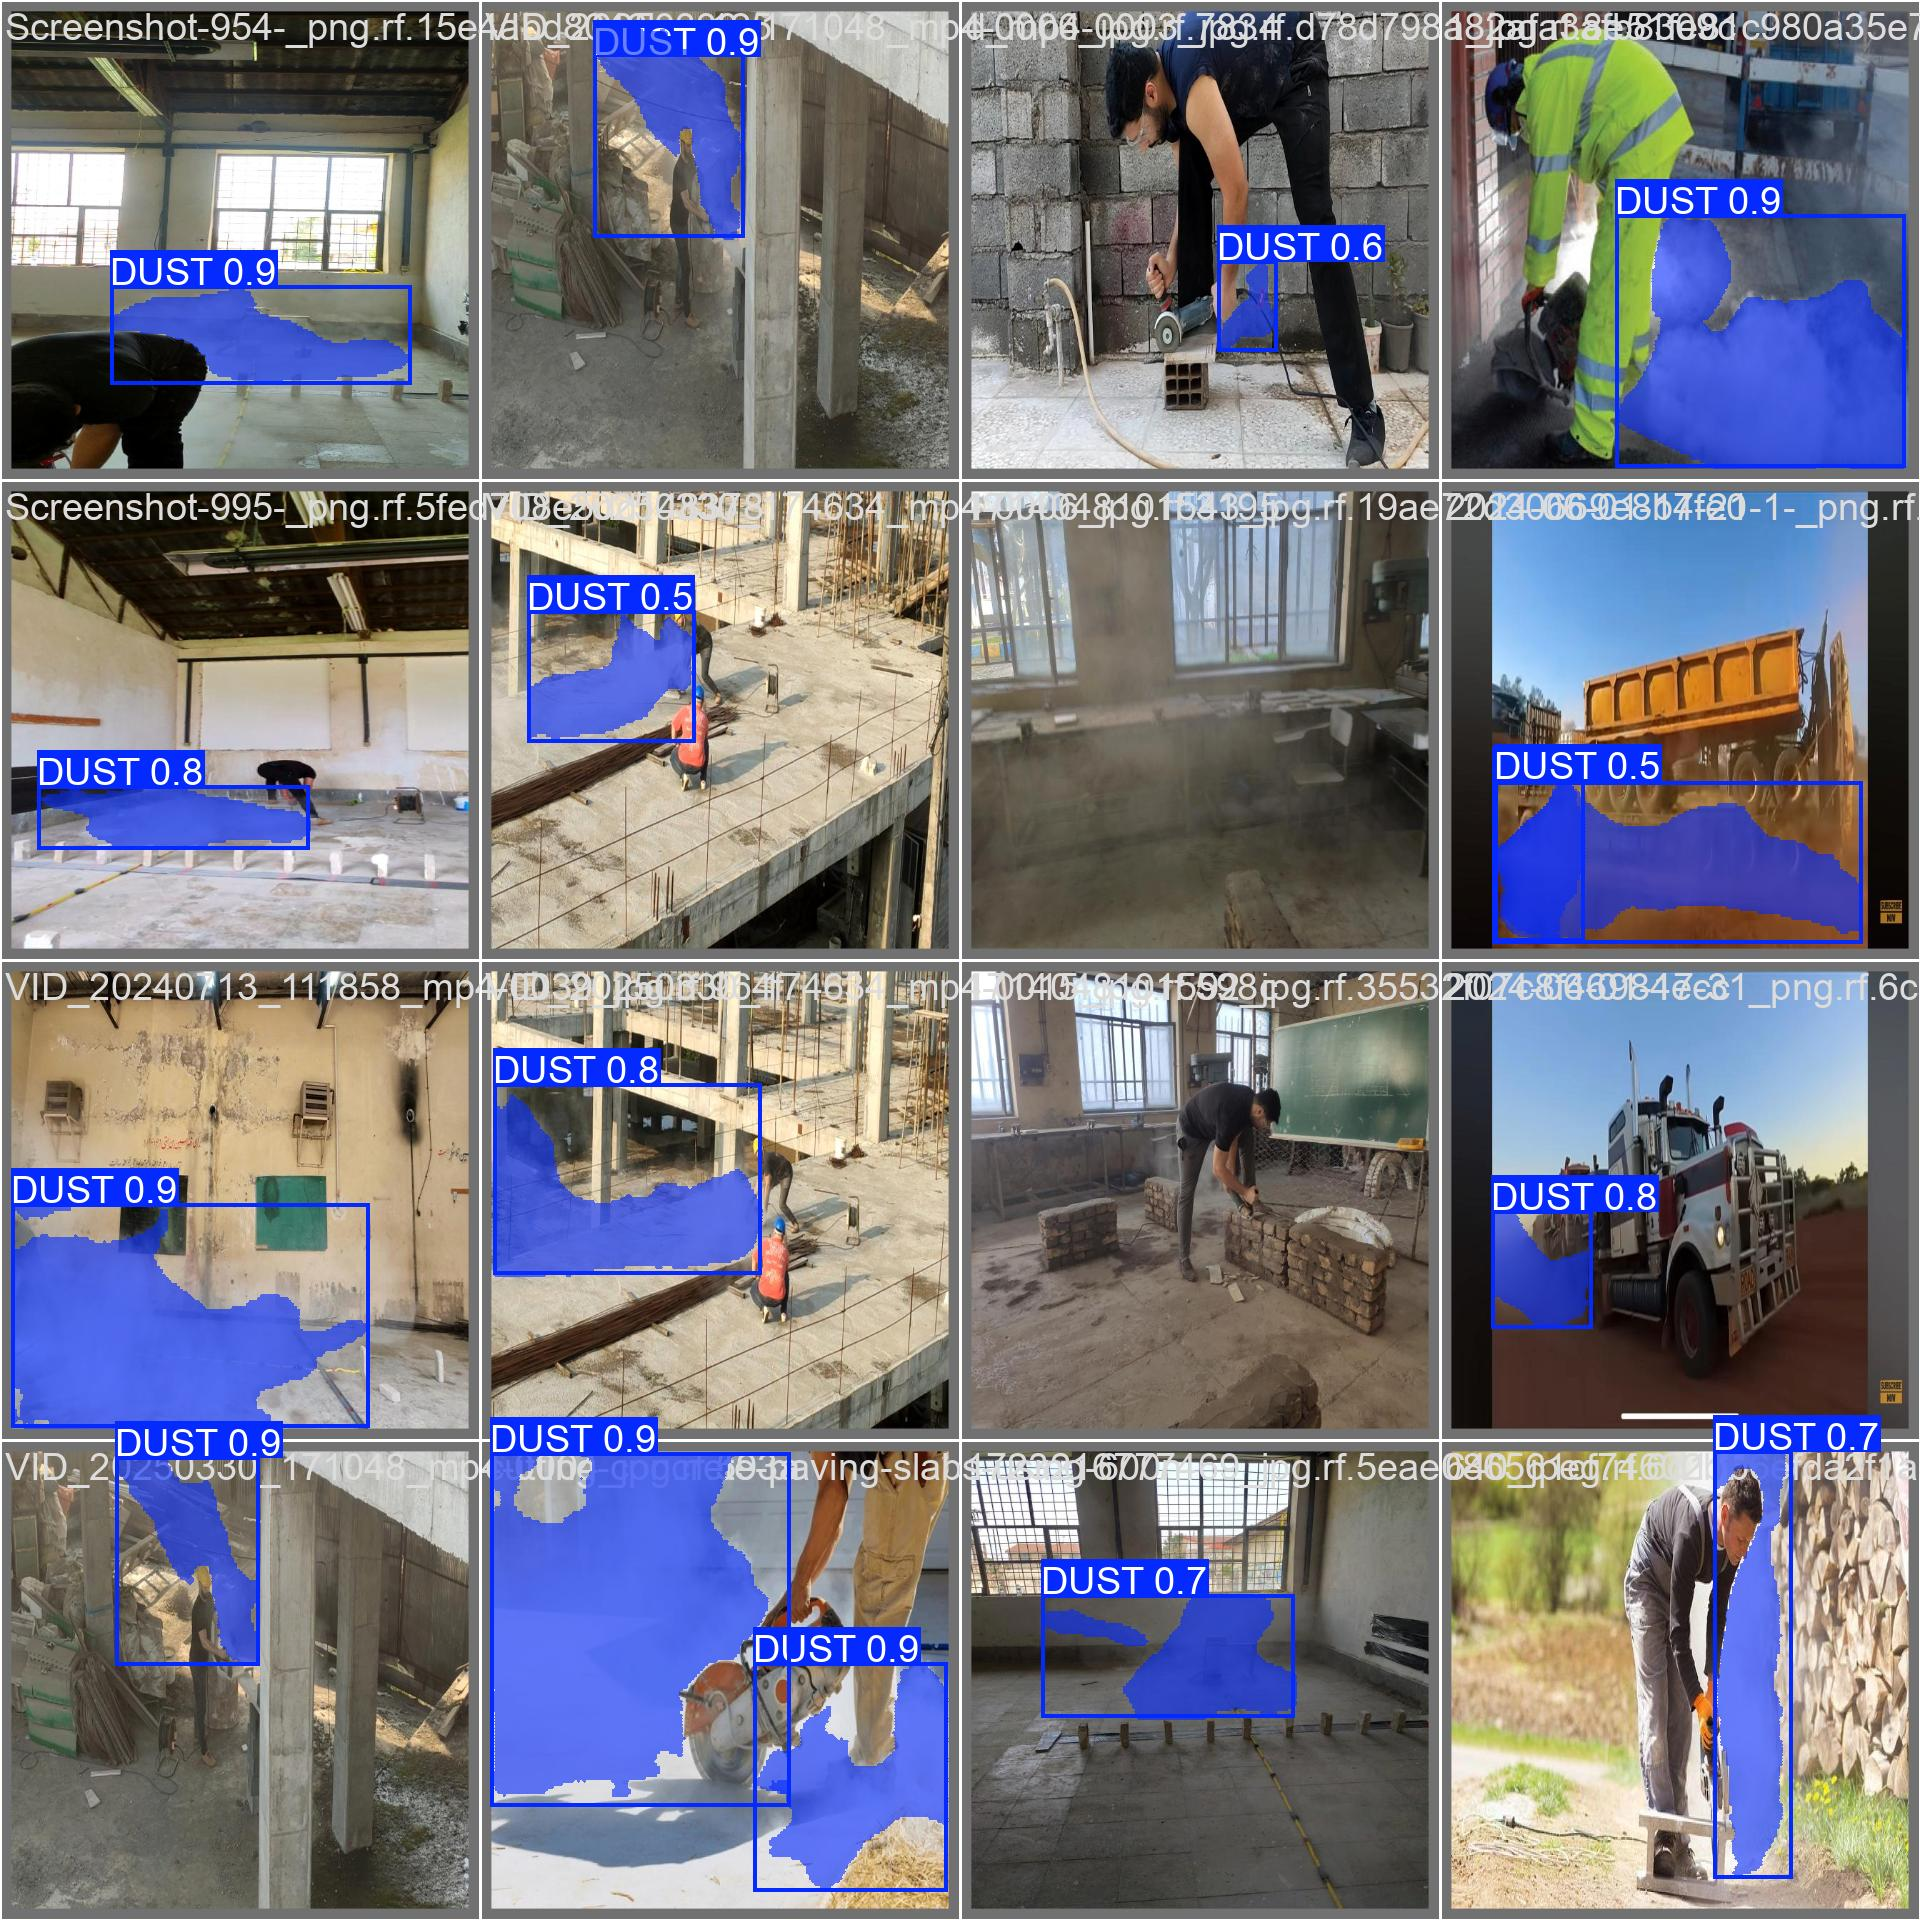

In [8]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [10]:
%cd {HOME}

!yolo task=segment mode=val model={HOME}/runs/segment/train/weights/last.pt data={dataset.location}/data.yaml

/content/{HOME}/datasets
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8l-seg summary (fused): 295 layers, 45,912,659 parameters, 0 gradients, 220.1 GFLOPs
val: Scanning /content/{HOME}/datasets/dust-detection-6/valid/labels.cache... 109 images, 1 backgrounds, 0 corrupt: 100% 109/109 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% 7/7 [00:07<00:00,  1.05s/it]
                   all        109        149      0.828      0.664      0.717      0.377      0.865      0.644      0.725      0.328
Speed: 6.3ms preprocess, 40.0ms inference, 0.0ms loss, 4.3ms postprocess per image
Results saved to runs/segment/val2
💡 Learn more at https://docs.ultralytics.com/modes/val


## Inference with Custom Model

In [11]:
!pip install --upgrade numpy
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 94.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ultralytics 8.2.103 requires numpy<2.0.0,>=1.23.0, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
Looking in indexes: https://download.pytorch.org/whl/cu118


In [11]:
%cd {HOME}
!yolo task=segment mode=predict model={HOME}/datasets/runs/segment/train/weights/best.pt conf=0.25 source={HOME}/datasets/dust-detection-6/test/images save=true

/content/{HOME}
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8l-seg summary (fused): 295 layers, 45,912,659 parameters, 0 gradients, 220.1 GFLOPs

image 1/45 /content/{HOME}/datasets/dust-detection-6/test/images/03-1-_jpg.rf.cb17c379c74a9316357e2416370f1b6a.jpg: 640x640 1 DUST, 76.1ms
image 2/45 /content/{HOME}/datasets/dust-detection-6/test/images/170999564_jpg.rf.e836d6f3ee90f153752d126afa858b29.jpg: 640x640 2 DUSTs, 71.5ms
image 3/45 /content/{HOME}/datasets/dust-detection-6/test/images/2024-06-01-17-41-1-_png.rf.67bb87ca57f97bff4056a0bb2e3cc35f.jpg: 640x640 1 DUST, 71.4ms
image 4/45 /content/{HOME}/datasets/dust-detection-6/test/images/IMG_2472_mov-0027_jpg.rf.15f6bcb8b0dc7ff7161ae87a9908260b.jpg: 640x640 1 DUST, 66.2ms
image 5/45 /content/{HOME}/datasets/dust-detection-6/test/images/IMG_2476_jpeg.rf.d07cb7d5bf53699bf9af154f131a81d9.jpg: 640x640 1 DUST, 41.0ms
image 6/45 /content/{HOME}/datasets/dust-detection-6/test/images/IMG_2487_m

In [14]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'{HOME}/runs/segment/predict2/*.jpg')[:3]:
      display(Image(filename=image_path, height=600))
      print("\n")

In [15]:

#سه تایی بهتر
import os
import cv2
import numpy as np
from ultralytics import YOLO

# --- کد مربوط به تشخیص گرد و غبار ---

# بارگیری مدل YOLOv8-seg
model_dust = YOLO("/content/{HOME}/datasets/runs/segment/train/weights/best.pt")  # Replace with your model path

# مسیر فایل ورودی و خروجی
input_file = "/content/IMG_2945.MOV"  # Replace with your input file path
output_folder = "/content/output1"  # Replace with your output folder

# ایجاد پوشه خروجی اگر وجود ندارد
os.makedirs(output_folder, exist_ok=True)

# Load the video file
cap = cv2.VideoCapture(input_file)

# Get video properties for output video
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(5))

# Define the codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Use 'mp4v' for MP4 format
out_dust = cv2.VideoWriter(os.path.join(output_folder, 'output.mp4'), fourcc, fps, (frame_width, frame_height))

# Process video frame by frame
frame_count = 0
dust_count = 0  # Initialize dust_count to 0
no_detection_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    current_time = frame_count / fps  # Calculate current time in seconds

    # انجام پیش بینی با مدل
    results = model_dust.predict(frame, conf=0.25)  # Adjust confidence as needed

    # Check if any objects were detected
    if results[0].boxes.data.shape[0] == 0:
        no_detection_count += 1
    else:
        # Check if masks are found before accessing them
        if results[0].masks is not None:
            # استخراج ماسک های سگمنت
            masks = results[0].masks.data

            # Flag to track if dust has been counted in this frame
            dust_counted_in_frame = False

            # Iterate through detected objects and their masks
            for i, mask in enumerate(masks):
                # Get the class ID, bounding box, and confidence for the current object
                class_id = results[0].boxes.cls[i].item()
                bbox = results[0].boxes.xyxy[i].cpu().numpy().astype(int)
                conf = results[0].boxes.conf[i].item()  # Get confidence

                # Check if the detected object is 'dust' (class_id 0)
                if class_id == 0 and not dust_counted_in_frame:
                    dust_count += 1  # Increment dust_count only once per frame
                    dust_counted_in_frame = True  # Set the flag to True

                    color = [0, 255, 255]  # yellow (BGR)
                    alpha = 0.7  # Transparency (0.0 - 1.0)

                    # Resize the mask to match the frame dimensions
                    mask = cv2.resize(mask.cpu().numpy(), (frame_width, frame_height))

                    # Apply color to the masked area with transparency
                    for r in range(frame_height):
                        for c in range(frame_width):
                            if mask[r, c]:
                                frame[r, c] = frame[r, c] * (1 - alpha) + np.array(color) * alpha

                    # Draw bounding box and label with confidence
                    cv2.rectangle(frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)
                    label = f"dust: {conf:.2f}"  # Class name and confidence
                    cv2.putText(frame, label, (bbox[0], bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # Display frame number, time, and counts on the frame
    info_text_dust = f"Frame: {frame_count}, Time: {current_time:.2f}s, dust: {dust_count}, No Detection: {no_detection_count}"
    cv2.putText(frame, info_text_dust, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

    # Write the processed frame to the output video
    out_dust.write(frame)

# Release everything when the job is finished
cap.release()
out_dust.release()
print("Segmentation complete. Output video saved to:", output_folder)


# --- کد مربوط به تشخیص ماسک (اصلاح شده) ---

model_mask = YOLO('/content/mask_3.pt')  # مدل خود را اینجا جایگزین کنید

# مسیر فایل ویدیویی ورودی
video_path = '/content/output1/output.mp4'

# مسیر فایل ویدیویی خروجی
output_path = '/content/mask.mp4'  # مسیر فایل خروجی را اینجا مشخص کنید

# خواندن فایل ویدیویی ورودی
cap = cv2.VideoCapture(video_path)

# دریافت اطلاعات ویدیو
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# ایجاد شیء VideoWriter برای نوشتن فایل ویدیویی خروجی
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_mask = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Initialize counters for the entire video
total_mask_count = 0
total_nomask_count = 0
total_no_detection_count = 0
D = 0  # Initialize the new counter D

frame_count = 0  # Initialize frame_count

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1  # Increment frame_count
    current_time = frame_count / fps  # Calculate current time in seconds

    # اجرای شناسایی با YOLOv8
    results = model_mask(frame)

    # Reset counters for the current frame
    frame_mask_count = 0
    frame_nomask_count = 0
    frame_no_detection_count = 0

    # Check if any objects were detected in the current frame
    if results[0].boxes.data.shape[0] == 0:
        frame_no_detection_count += 1
        total_no_detection_count += 1  # Update total count
    else:
        D += 1  # Increment D only once if any mask or nomask is detected in the frame
        boxes = results[0].boxes
        for box in boxes:
            cls = int(box.cls[0])
            conf = box.conf[0]
            xyxy = box.xyxy[0].tolist()

            # تعیین رنگ جعبه مرزی و لیبل
            if cls == 0:  # کلاس nomask
                color = (0, 0, 255)  # قرمز
                label = 'nomask'
                frame_nomask_count += 1
                total_nomask_count += 1  # Update total count
            else:  # کلاس mask
                color = (0, 255, 0)  # سبز
                label = 'mask'
                frame_mask_count += 1
                total_mask_count += 1  # Update total count

            # رسم جعبه مرزی و لیبل
            cv2.rectangle(frame, (int(xyxy[0]), int(xyxy[1])), (int(xyxy[2]), int(xyxy[3])), color, 2)
            cv2.putText(frame, f'{label} {conf:.2f}', (int(xyxy[0]), int(xyxy[1]) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    # Display total counts for mask information
    counts_text_mask = f"Total(mask,nomask):({total_mask_count},{total_nomask_count}),(M,NM)({frame_mask_count},{frame_nomask_count}),No Detection:{total_no_detection_count}, D:{D}"

    # Get text size for positioning (with smaller font scale)
    (text_width_mask, text_height_mask), _ = cv2.getTextSize(counts_text_mask, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)  # Reduced font scale to 0.4

    # Calculate text position (bottom left)
    text_x_mask = 10
    text_y_mask = height - text_height_mask - 10

    # Set background color based on detection
    if results[0].boxes.data.shape[0] == 0:  # No Detection
        bg_color = (0, 255, 0)  # Green for No Detection
    elif frame_nomask_count > frame_mask_count:  # More no masks than masks
        bg_color = (0, 0, 255)  # Red for more no masks
    else:
        bg_color = (0, 255, 0)  # Green for more masks or equal

    cv2.rectangle(frame, (text_x_mask - 5, text_y_mask - 5), (text_x_mask + text_width_mask + 5, text_y_mask + text_height_mask + 5), bg_color, -1)

    # Write text on the frame (with white color)
    cv2.putText(frame, counts_text_mask, (text_x_mask, text_y_mask + text_height_mask), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)  # Reduced font scale to 0.4

    out_mask.write(frame)

# آزاد کردن منابع
cap.release()
out_mask.release()


# --- کد مربوط به تشخیص person (اصلاح شده) ---

model_person = YOLO('/content/yolov8l.pt')  # Replace with your model path

# Specify video input and output paths
video_path = '/content/mask.mp4'  # Replace with your input video path
output_path = '/content/person.mp4'  # Replace with your desired output path

# Read the input video
cap = cv2.VideoCapture(video_path)

# Get video information
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Create a video writer object
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_person = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Initialize counters
total_frames = 0
person_count = 0
no_detection_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    total_frames += 1

    # Perform object detection with YOLOv8
    results = model_person(frame, classes=[0])  # Detect only class 0 (person)

    # Process detection results
    detected_person_in_frame = False
    for r in results:
        boxes = r.boxes
        for box in boxes:
            cls = int(box.cls[0])
            conf = box.conf[0]
            xyxy = box.xyxy[0].tolist()

            # Draw bounding box and label
            color = (255, 255, 255)  # white color for person
            label = model_person.names[cls]
            cv2.rectangle(frame, (int(xyxy[0]), int(xyxy[1])), (int(xyxy[2]), int(xyxy[3])), color, 2)
            cv2.putText(frame, f'{label} {conf:.2f}', (int(xyxy[0]), int(xyxy[1]) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

            if cls == 0:
                detected_person_in_frame = True

    if detected_person_in_frame:
        person_count += 1
    else:
        no_detection_count += 1

    # Display information on the frame
    ratio = person_count / total_frames if total_frames else 0  # Avoid division by zero
    info_text = f"Ratio:{ratio:.2f},Person:{person_count},No Detection Count:{no_detection_count}"

    # Get text size for positioning
    (text_width, text_height), _ = cv2.getTextSize(info_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)

    # Calculate text position (bottom left, above mask information) with margin adjustments
    text_x = 10  # Adjust margin as needed
    text_y = height - 2 * text_height - 30  # Adjust vertical position and margin

    # Define color and transparency (white color for person information)
    color = (255, 255, 255)  # White color
    # alpha = 0.7 # Transparency - Not used here but can be applied for background if needed

    # Draw bounding box and label with confidence (Not applicable here, but included for format consistency)
    # cv2.rectangle(frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2) # Commenting out as not relevant

    # Write text on the frame (with white color, maintain position using text_x, text_y)
    cv2.putText(frame, info_text, (text_x, text_y + text_height), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 1)  # Adjusted font scale and thickness


    out_person.write(frame)

# Release resources
cap.release()
out_person.release()

Streaming output truncated to the last 5000 lines.

0: 640x384 (no detections), 27.8ms
Speed: 3.6ms preprocess, 27.8ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 26.6ms
Speed: 4.0ms preprocess, 26.6ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 28.5ms
Speed: 3.6ms preprocess, 28.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 26.5ms
Speed: 4.2ms preprocess, 26.5ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 26.6ms
Speed: 3.9ms preprocess, 26.6ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 27.3ms
Speed: 3.8ms preprocess, 27.3ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no detections), 26.7ms
Speed: 3.8ms preprocess, 26.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 (no de

100%|██████████| 83.7M/83.7M [00:02<00:00, 39.3MB/s]



0: 640x384 1 person, 41.4ms
Speed: 2.5ms preprocess, 41.4ms inference, 7.1ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 30.6ms
Speed: 3.7ms preprocess, 30.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 30.7ms
Speed: 3.8ms preprocess, 30.7ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 30.6ms
Speed: 4.0ms preprocess, 30.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 30.6ms
Speed: 3.6ms preprocess, 30.6ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 30.6ms
Speed: 3.9ms preprocess, 30.6ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 28.9ms
Speed: 3.9ms preprocess, 28.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 25.7ms
Speed: 5.0ms preprocess, 25.7ms inference, 1.7ms postprocess per image at shape (1, 3, 64

## Save & Deploy model

Once you have finished training your YOLOv8 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload and your model weights to Roboflow Deploy for autolabeling, autoscaling inference, and storage for later use.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) supports uploading YOLOv8 weights.

Run this cell to save your model weights:

In [ ]:
project.version(dataset.version).deploy(model_type="yolov8-seg", model_path=f"{HOME}/runs/segment/train/")

Dependency ultralytics==8.0.196 is required but found version=8.2.103, to fix: `pip install ultralytics==8.0.196`
Would you like to continue with the wrong version of ultralytics? y/n: y
View the status of your deployment at: https://app.roboflow.com/model-examples/car-parts-instance-segmentation/3
Share your model with the world at: https://universe.roboflow.com/model-examples/car-parts-instance-segmentation/model/3


Follow the links above to check if the upload succeeded. It may take a couple of minutes until the model is visible to the `roboflow` SDK.

In [ ]:
# Run inference on your model on a persistant, auto-scaling, cloud API

# Load model
model = project.version(dataset.version).model
assert model, "Model deployment is still loading"

# Choose a random test image
import os, random
test_set_loc = dataset.location + "/test/images/"
random_test_image = random.choice(os.listdir(test_set_loc))
print("running inference on " + random_test_image)

pred = model.predict(test_set_loc + random_test_image).json()
pred

running inference on 0374638_as-2885603_jpg.rf.6c1803fe031371708c4c54ef436e6dc2.jpg


{'predictions': [{'x': 527.5,
   'y': 404.0,
   'width': 521.0,
   'height': 338.0,
   'confidence': 0.9511378407478333,
   'class': 'Rearbumper',
   'points': [{'x': 346.25, 'y': 236.25},
    {'x': 343.75, 'y': 238.125},
    {'x': 343.75, 'y': 239.0625},
    {'x': 341.25, 'y': 240.9375},
    {'x': 341.25, 'y': 241.875},
    {'x': 340.0, 'y': 242.8125},
    {'x': 340.0, 'y': 244.6875},
    {'x': 338.75, 'y': 245.625},
    {'x': 338.75, 'y': 246.5625},
    {'x': 336.25, 'y': 248.4375},
    {'x': 336.25, 'y': 249.375},
    {'x': 335.0, 'y': 250.3125},
    {'x': 335.0, 'y': 253.125},
    {'x': 333.75, 'y': 254.0625},
    {'x': 333.75, 'y': 255.0},
    {'x': 331.25, 'y': 256.875},
    {'x': 331.25, 'y': 257.8125},
    {'x': 330.0, 'y': 258.75},
    {'x': 330.0, 'y': 262.5},
    {'x': 328.75, 'y': 263.4375},
    {'x': 328.75, 'y': 264.375},
    {'x': 326.25, 'y': 266.25},
    {'x': 326.25, 'y': 267.1875},
    {'x': 325.0, 'y': 268.125},
    {'x': 325.0, 'y': 271.875},
    {'x': 321.25, 'y':

# Deploy Your Model to the Edge

![Roboflow Inference banner](https://blog.roboflow.com/content/images/2023/08/banner.png)

In addition to using the Roboflow hosted API for deployment, you can use [Roboflow Inference](https://inference.roboflow.com), an open source inference solution that has powered millions of API calls in production environments. Inference works with CPU and GPU, giving you immediate access to a range of devices, from the NVIDIA Jetson to TRT-compatible devices to ARM CPU devices.

With Roboflow Inference, you can self-host and deploy your model on-device. You can deploy applications using the [Inference Docker containers](https://inference.roboflow.com/quickstart/docker/) or the pip package.

For example, to install Inference on a device with an NVIDIA GPU, we can use:

```
docker pull roboflow/roboflow-inference-server-gpu
```

Then we can run inference via HTTP:

```python
import requests

workspace_id = ""
model_id = ""
image_url = ""
confidence = 0.75
api_key = ""

infer_payload = {
    "image": {
        "type": "url",
        "value": image_url,
    },
    "confidence": confidence,
    "iou_threshold": iou_thresh,
    "api_key": api_key,
}
res = requests.post(
    f"http://localhost:9001/{workspace_id}/{model_id}",
    json=infer_object_detection_payload,
)

predictions = res.json()
```

Above, set your Roboflow workspace ID, model ID, and API key.

- [Find your workspace and model ID](https://docs.roboflow.com/api-reference/workspace-and-project-ids?ref=blog.roboflow.com)
- [Find your API key](https://docs.roboflow.com/api-reference/authentication?ref=blog.roboflow.com#retrieve-an-api-key)

Also, set the URL of an image on which you want to run inference. This can be a local file.

_To use your YOLOv8 model commercially with Inference, you will need a Roboflow Enterprise license, through which you gain a pass-through license for using YOLOv8. An enterprise license also grants you access to features like advanced device management, multi-model containers, auto-batch inference, and more._

## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.